In [24]:
RUN_TEST = False

In [25]:
import numpy as np
import import_ipynb

from A_market_model_greeks import *
from B_MDP_state_generator import *

In [26]:
def _pricing_params_with_sigma(env):
    """Retourne un dict params identique à env['params'] mais avec sigma0 = env['sigma']."""
    # env['sigma'] current volatility of the environment (changing daily)
    p = dict(env["params"])
    p["sigma0"] = float(env["sigma"])
    return p


def _clip_action_01(action):
    # accepte float / np scalar  
    # to force the action to be between 0 and 1
    a = float(action)
    return max(0.0, min(1.0, a))

In [27]:
def init_env(params, seed=None):
    """
    Crée une structure d'environnement + RNG.
    """
    env = {
        "params": dict(params),
        "rng": np.random.default_rng(seed),
        "t": 0,
        "S": float(params.get("S0", 100.0)),
        "sigma": float(params.get("sigma0", 0.2)),
        "portfolio": [],
        "P_prev": 0.0,
        "done": False,
    }
    return env

In [28]:
def env_reset(env, S0=None, sigma0=None, seed=None):
    """
    Reset épisode: portefeuille vide, t=0, calcule l'état initial.
    """
    if seed is not None:
        env["rng"] = np.random.default_rng(seed)

    p = env["params"]
    env["t"] = 0
    env["done"] = False

    env["S"] = float(p["S0"] if S0 is None else S0)
    env["sigma"] = float(p["sigma0"] if sigma0 is None else sigma0)

    env["portfolio"] = []
    # P_prev = valeur portefeuille (vide => 0)
    env["P_prev"] = 0.0

    # grecs init
    params_day = _pricing_params_with_sigma(env)
    port_g = portfolio_greeks(env["portfolio"], env["S"], params_day)

    T_hedge = p["T_hedge_days"] / 252
    hedge_g = hedging_option(env["S"], T_hedge, params_day)

    state = build_state(env["S"], port_g, hedge_g)
    return state, env

In [29]:
def simulate_client_flow_one_day(portfolio, S, params, rng):
    """
    Simule les arrivées clients du jour et append au portefeuille.
    """
    # Poisson + signes via rng (random number generator)
    n = rng.poisson(params["lambda_day"])
    signs = rng.choice([1, -1], size=n)

    for s in signs:
        portfolio.append(create_client_option(s, S, params))

    return portfolio

In [30]:
def mark_to_market_update(env):
    """
    Avance le marché d'un jour via SABR discret (Euler).
    """
    p = env["params"]
    dt = p["dt"]

    # chocs corrélés via env rng
    z1 = env["rng"].normal()
    eps = env["rng"].normal()
    rho = p["rho"]
    z2 = rho * z1 + np.sqrt(1 - rho**2) * eps

    S_new, sigma_new = simulate_sabr_step(
        S=env["S"],
        sigma=env["sigma"],
        dt=dt,
        r=p["r"],
        q=p["q"],
        v=p["v"],
        rho=rho,
        z1=z1,
        z2=z2
    )

    # petite sécurité numérique (vol > 0)
    sigma_new = max(float(sigma_new), 1e-8)

    return float(S_new), float(sigma_new)

In [31]:
def advance_portfolio_one_day(portfolio, dt):
    return update_time_to_maturity(portfolio, dt)

In [32]:
def compute_H_max(port_greeks, hedge_greeks):
    return max_hedge_position(port_greeks, hedge_greeks)

In [33]:
def env_step(env, action):
    """
    1 journée complète.
    Retourne: next_state, reward, done, info
    """
    if env["done"]:
        # convention : step sur env terminé => pas de mouvement
        params_day = _pricing_params_with_sigma(env)
        port_g = portfolio_greeks(env["portfolio"], env["S"], params_day)
        T_hedge = env["params"]["T_hedge_days"] / 252
        hedge_g = hedging_option(env["S"], T_hedge, params_day)
        return build_state(env["S"], port_g, hedge_g), 0.0, True, {"msg": "env already done"}

    p = env["params"]
    dt = p["dt"]
    T_hedge = p["T_hedge_days"] / 252

    a = _clip_action_01(action)

    # ---- 1) Arrivées clients
    params_day = _pricing_params_with_sigma(env)
    env["portfolio"] = simulate_client_flow_one_day(env["portfolio"], env["S"], params_day, env["rng"])

    # ---- 2) Greeks portefeuille avant hedge
    port_g_before = portfolio_greeks(env["portfolio"], env["S"], params_day)

    # ---- 3) Option de hedge ATM (du jour)
    hedge_today = hedging_option(env["S"], T_hedge, params_day)

    # ---- 4) H_max puis H
    H_max = compute_H_max(port_g_before, hedge_today)
    # si H_max inf ou nan (cas pathologique), on force 0
    if not np.isfinite(H_max) or H_max < 0:
        H_max = 0.0

    H = apply_hedge(a, H_max)

    # transaction cost sur le trade hedge du jour
    V = hedge_today["price"]
    cost = transaction_cost(V, H, p["kappa"])

    # ---- 5) Ajouter l'option hedge au portefeuille (elle "reste" et décroit en maturité)
    # On approxime: instrument ATM strike= S du jour, maturité T_hedge.
    if abs(H) > 0:
        env["portfolio"].append({
            "sign": float(H),
            "K": float(env["S"]),
            "T": float(T_hedge),
            "price": float(hedge_today["price"]),
            "gamma": float(hedge_today["gamma"]),
            "vega": float(hedge_today["vega"])
        })

    # Greeks après hedge (utile debug)
    port_g_after = portfolio_greeks(env["portfolio"], env["S"], params_day)

    # ---- 6) Move marché (S, sigma) d'un jour
    S_new, sigma_new = mark_to_market_update(env)

    # ---- 7) Update maturités
    env["portfolio"] = advance_portfolio_one_day(env["portfolio"], dt)

    # ---- 8) P_prev -> P_curr (mark-to-market des options)
    P_prev = float(env["P_prev"])

    # on valorise au nouveau spot + nouvelle vol instantanée
    S_old = env["S"]
    sigma_old = env["sigma"]
    env["S"] = S_new
    env["sigma"] = sigma_new

    params_new = _pricing_params_with_sigma(env)
    P_curr = float(portfolio_value(env["portfolio"], env["S"], params_new))

    # ---- 9) Reward
    reward = float(compute_reward(P_prev, P_curr, V, H, p["kappa"]))

    # update env memory
    env["P_prev"] = P_curr

    # incrément temps + done
    env["t"] += 1
    done = env["t"] >= int(p["T_days"])
    env["done"] = bool(done)

    # ---- 10) Next state
    port_g_next = portfolio_greeks(env["portfolio"], env["S"], params_new)
    hedge_next = hedging_option(env["S"], T_hedge, params_new)
    next_state = build_state(env["S"], port_g_next, hedge_next)

    info = {
        "t": env["t"],
        "action": a,
        "H_max": float(H_max),
        "H": float(H),
        "V": float(V),
        "cost": float(cost),
        "P_prev": float(P_prev),
        "P_curr": float(P_curr),
        "dP": float(P_curr - P_prev),
        "S_old": float(S_old),
        "S_new": float(S_new),
        "sigma_old": float(sigma_old),
        "sigma_new": float(sigma_new),
        "gamma_before": float(port_g_before["gamma"]),
        "vega_before": float(port_g_before["vega"]),
        "gamma_after": float(port_g_after["gamma"]),
        "vega_after": float(port_g_after["vega"]),
        "portfolio_size": len(env["portfolio"]),
    }

    return next_state, reward, done, info

Episode terminé: True
Reward total: 91.28939323412739
P&L final (P_T - P_0): 92.27364288292594


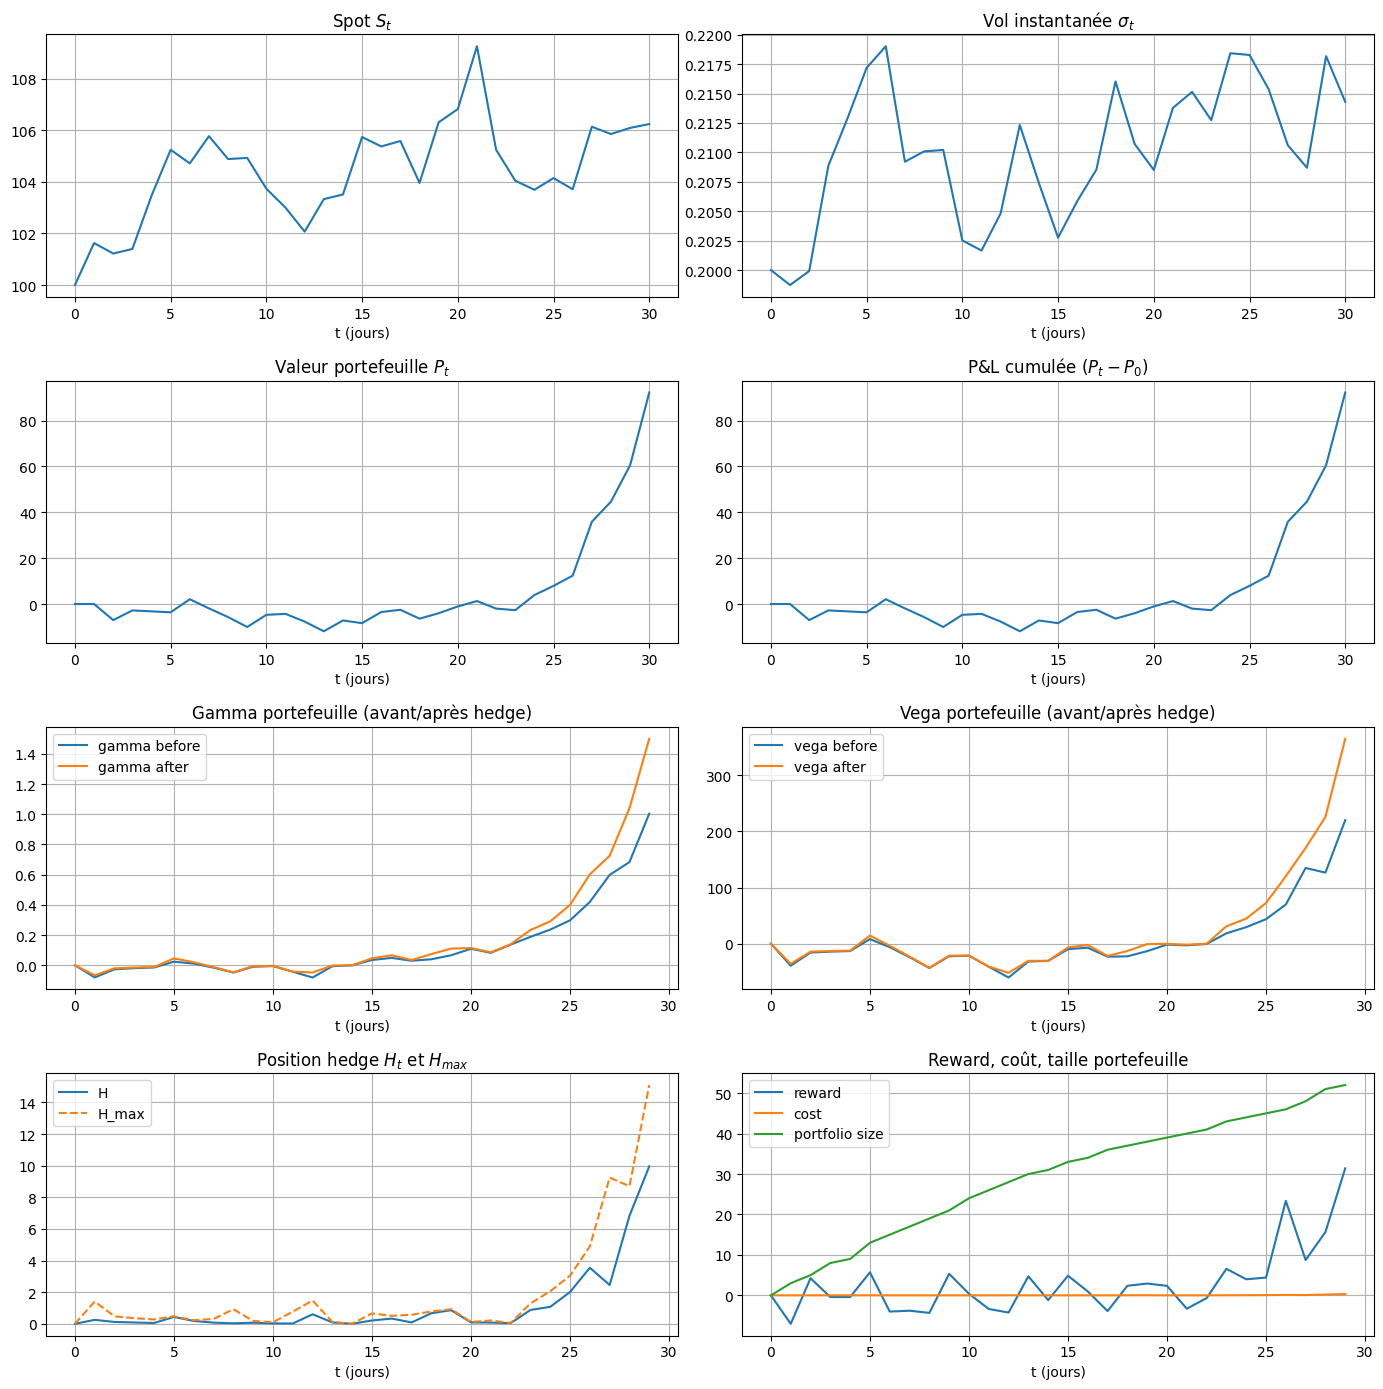

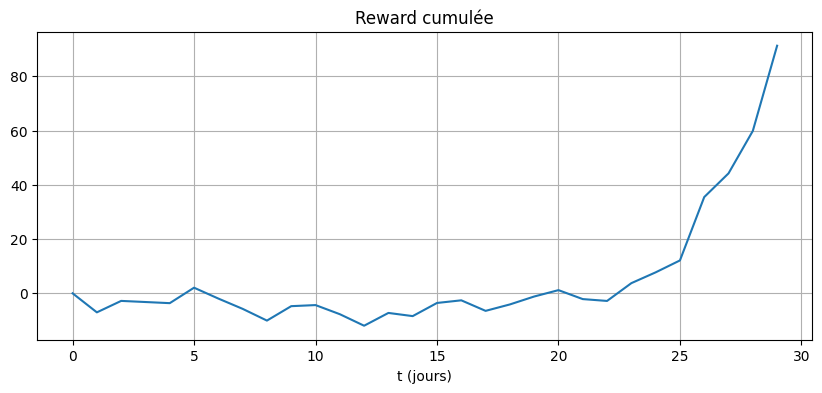

In [ ]:
RUN_TEST = False

if RUN_TEST:
    import matplotlib.pyplot as plt
    import numpy as np

    params = {
        "r": 0.01,
        "q": 0.0,
        "v": 0.5,
        "rho": -0.3,
        "lambda_day": 1.0,
        "kappa": 0.01,
        "T_days": 30,
        "dt": 1/252,
        "T_client_days": 60,
        "T_hedge_days": 30,
        "S0": 100.0,
        "sigma0": 0.2,
    }

    env = init_env(params, seed=123)
    state, env = env_reset(env)

    # --- historiques
    t_hist = []
    S_hist = []
    sigma_hist = []
    P_hist = []
    dP_hist = []
    reward_hist = []
    cost_hist = []
    H_hist = []
    Hmax_hist = []
    port_size_hist = []
    gamma_b_hist = []
    vega_b_hist = []
    gamma_a_hist = []
    vega_a_hist = []

    P0 = env["P_prev"]

    for _ in range(params["T_days"]):
        # état avant step (t courant)
        t_hist.append(env["t"])
        S_hist.append(env["S"])
        sigma_hist.append(env["sigma"])
        P_hist.append(env["P_prev"])

        # action random (policy de test)
        action = env["rng"].random()

        # step
        next_state, r, done, info = env_step(env, action)

        reward_hist.append(r)
        cost_hist.append(info["cost"])
        H_hist.append(info["H"])
        Hmax_hist.append(info["H_max"])
        port_size_hist.append(info["portfolio_size"])

        gamma_b_hist.append(info["gamma_before"])
        vega_b_hist.append(info["vega_before"])
        gamma_a_hist.append(info["gamma_after"])
        vega_a_hist.append(info["vega_after"])

        dP_hist.append(info["dP"])

        if done:
            break

    # ajouter dernier point après la dernière step (optionnel, pour courbes alignées)
    t_hist.append(env["t"])
    S_hist.append(env["S"])
    sigma_hist.append(env["sigma"])
    P_hist.append(env["P_prev"])

    # --- conversions np
    t_hist = np.array(t_hist)
    S_hist = np.array(S_hist)
    sigma_hist = np.array(sigma_hist)
    P_hist = np.array(P_hist)

    reward_hist = np.array(reward_hist)
    cost_hist = np.array(cost_hist)
    H_hist = np.array(H_hist)
    Hmax_hist = np.array(Hmax_hist)
    port_size_hist = np.array(port_size_hist)

    gamma_b_hist = np.array(gamma_b_hist)
    vega_b_hist = np.array(vega_b_hist)
    gamma_a_hist = np.array(gamma_a_hist)
    vega_a_hist = np.array(vega_a_hist)

    dP_hist = np.array(dP_hist)

    pnl_cum = P_hist - P0
    reward_cum = np.cumsum(reward_hist)

    print("Episode terminé:", bool(env["done"]))
    print("Reward total:", float(np.sum(reward_hist)))
    print("P&L final (P_T - P_0):", float(pnl_cum[-1]))

    # --- plots
    fig, axs = plt.subplots(4, 2, figsize=(14, 14))
    axs = axs.flatten()

    # 1) Spot
    axs[0].plot(t_hist, S_hist)
    axs[0].set_title("Spot $S_t$")
    axs[0].set_xlabel("t (jours)")
    axs[0].grid(True)

    # 2) Vol instantanée
    axs[1].plot(t_hist, sigma_hist)
    axs[1].set_title("Vol instantanée $\\sigma_t$")
    axs[1].set_xlabel("t (jours)")
    axs[1].grid(True)

    # 3) Valeur portefeuille
    axs[2].plot(t_hist, P_hist)
    axs[2].set_title("Valeur portefeuille $P_t$")
    axs[2].set_xlabel("t (jours)")
    axs[2].grid(True)

    # 4) P&L cumulée
    axs[3].plot(t_hist, pnl_cum)
    axs[3].set_title("P&L cumulée $(P_t - P_0)$")
    axs[3].set_xlabel("t (jours)")
    axs[3].grid(True)

    # 5) Gamma avant/après hedge
    axs[4].plot(t_hist[:-1], gamma_b_hist, label="gamma before")
    axs[4].plot(t_hist[:-1], gamma_a_hist, label="gamma after")
    axs[4].set_title("Gamma portefeuille (avant/après hedge)")
    axs[4].set_xlabel("t (jours)")
    axs[4].grid(True)
    axs[4].legend()

    # 6) Vega avant/après hedge
    axs[5].plot(t_hist[:-1], vega_b_hist, label="vega before")
    axs[5].plot(t_hist[:-1], vega_a_hist, label="vega after")
    axs[5].set_title("Vega portefeuille (avant/après hedge)")
    axs[5].set_xlabel("t (jours)")
    axs[5].grid(True)
    axs[5].legend()

    # 7) Hedge H + Hmax
    axs[6].plot(t_hist[:-1], H_hist, label="H")
    axs[6].plot(t_hist[:-1], Hmax_hist, label="H_max", linestyle="--")
    axs[6].set_title("Position hedge $H_t$ et $H_{max}$")
    axs[6].set_xlabel("t (jours)")
    axs[6].grid(True)
    axs[6].legend()

    # 8) Rewards / coûts / taille portefeuille
    axs[7].plot(t_hist[:-1], reward_hist, label="reward")
    axs[7].plot(t_hist[:-1], cost_hist, label="cost")
    axs[7].plot(t_hist[:-1], port_size_hist, label="portfolio size")
    axs[7].set_title("Reward, coût, taille portefeuille")
    axs[7].set_xlabel("t (jours)")
    axs[7].grid(True)
    axs[7].legend()

    plt.tight_layout()
    plt.show()

    # plot séparé (souvent utile) : reward cumulée
    plt.figure(figsize=(10,4))
    plt.plot(t_hist[:-1], reward_cum)
    plt.title("Reward cumulée")
    plt.xlabel("t (jours)")
    plt.grid(True)
    plt.show()